**Install Dependencies**

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import torch, re
v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")

!pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo -q
!pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer -q
!pip install --no-deps unsloth -q
!pip install transformers==4.57.1 -q
!pip install --no-deps trl==0.22.2 -q
!pip install -U torchao -q

print("Dependencies installed-(Ignore dependency conflict warnings)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 MB 45.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 48.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 87.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 8.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.8.4 requires msgspec, which is not installed.
unsloth-zoo 2026.8.4 requires tyro; sys_platform != "darwin" or platform_machine != "arm64", which is not installed.
trl 1.9.2 requires datasets>=4.7.0, but you have datasets 4.3.0

**GPU Check**

In [3]:
import unsloth
from unsloth import FastVisionModel
import torch
import transformers
import datasets
import trl

print("System Info")
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")
print(f"TRL: {trl.__version__}")
print("\nCUDA available:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"Memory: {round(torch.cuda.get_device_properties(i).total_memory/1e9, 1)} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
System Info
PyTorch: 2.10.0+cu128
Transformers: 4.57.1
Datasets: 4.3.0
TRL: 0.22.2

CUDA available: True
GPU 0: Tesla T4
Memory: 15.6 GB


**Dataset Configuration**

In [4]:
SAMPLES_PER_PORTION = 20

PORTIONS = {
    "vqa": {
        "type": "bayanno_raw",
        "repo": "https://huggingface.co/datasets/Remian9080/Bangla-Bayanno-Full",
        "local_dir": "/kaggle/working/data_vqa",
    },
    # "captioning": {
    #     "type": "hf_datasets",
    #     "hf_id": "REPLACE_WITH_CAPTION_DATASET_ID",   # <-- TODO: HF ID
    #     "question_text": "এই ছবিতে কী দেখা যাচ্ছে তা বর্ণনা করো।",
    #     "image_field": "image",
    #     "answer_field": "caption",
    # },
    # "ocr": {
    #     "type": "hf_datasets",
    #     "hf_id": "REPLACE_WITH_OCR_DATASET_ID",        # <-- TODO: HF ID
    #     "question_text": "এই ছবিতে থাকা লেখাটি পড়ো।",
    #     "image_field": "image",
    #     "answer_field": "text",
    # },
     "text_instruction": {
        "type": "hf_datasets",
        "hf_id": "ai4bharat/indic-align",
        "config": "Dolly_T",
        "lang_field": "ben_Beng",
    },
}

print("Dataset Configuration Ready")
print(f"Samples per portion: {SAMPLES_PER_PORTION}")
print(f"Total samples: {SAMPLES_PER_PORTION * 2}")

Dataset Configuration Ready
Samples per portion: 20
Total samples: 40


**Load Model - QLoRA**

In [5]:
print("Loading Qwen3-VL-8B-Instruct in 4-bit")
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct",
    load_in_4bit = True,
    use_gradient_checkpointing = "unsloth",
)
print("Model loaded")

print("Configuring LoRA")
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)
print("LoRA configured")
print(f"Trainable parameters: {model.num_parameters(only_trainable=True):,}")

Loading Qwen3-VL-8B-Instruct in 4-bit
==((====))==  Unsloth 2026.8.5: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded
Configuring LoRA
LoRA configured
Trainable parameters: 43,646,976


**Collect Samples — Portion 1: VQA (Bangla-Bayanno)**

In [6]:
import json, os, random
random.seed(3407)

print("Loading VQA data")
os.makedirs(PORTIONS["vqa"]["local_dir"], exist_ok=True)
!git lfs install -q
!git clone {PORTIONS["vqa"]["repo"]} {PORTIONS["vqa"]["local_dir"]} -q

with open(os.path.join(PORTIONS["vqa"]["local_dir"], "qa.json"), "r", encoding="utf-8") as f:
    vqa_raw = json.load(f)

print(f"VQA total: {len(vqa_raw)} entries")
vqa_sample = random.sample(vqa_raw, SAMPLES_PER_PORTION)
print(f"Selected {len(vqa_sample)} samples")

Loading VQA data
Error: unknown shorthand flag: 'q' in -q
git lfs install [options]

Perform the following actions to ensure that Git LFS is setup properly:

* Set up the clean and smudge filters under the name "lfs" in the global Git
  config.
* Install a pre-push hook to run git lfs pre-push for the current repository,
  if run from inside one. If "core.hooksPath" is configured in any Git
  configuration (and supported, i.e., the installed Git version is at least
  2.9.0), then the pre-push hook will be installed to that directory instead.
  
Options:

Without any options, git lfs install will only setup the "lfs" smudge and clean
filters if they are not already set.

* --force:
    Sets the "lfs" smudge and clean filters, overwriting existing values.
* --local:
    Sets the "lfs" smudge and clean filters in the local repository's git
    config, instead of the global git config (~/.gitconfig).
* --worktree:
    Sets the "lfs" smudge and clean filters in the current working tree's
  

In [7]:
from PIL import Image

def vqa_to_conv(entry):
    img_path = os.path.join(PORTIONS["vqa"]["local_dir"], "images", entry["image_file"])
    image = Image.open(img_path).convert("RGB")
    return {
        "messages": [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": entry["question_bn"]},
            ]},
            {"role": "assistant", "content": [{"type": "text", "text": entry["answer_bn"]}]},
        ],
        "portion": "vqa",
    }

vqa_examples = [vqa_to_conv(e) for e in vqa_sample]
print(f"VQA examples ready: {len(vqa_examples)}")

VQA examples ready: 20


**Collect Samples — Portion 2: Captioning**

In [ ]:
#from datasets import load_dataset

#print("Loading Captioning data")
#cap_ds = load_dataset(PORTIONS["captioning"]["hf_id"], split="train")
#print(f"Captioning columns: {cap_ds.column_names}")

#cap_idx = random.sample(range(len(cap_ds)), SAMPLES_PER_PORTION)

#def caption_to_conv(row):
    #return {
        #"messages": [
            #{"role": "user", "content": [
                #{"type": "image", "image": row[PORTIONS["captioning"]["image_field"]]},
                #{"type": "text", "text": PORTIONS["captioning"]["question_text"]},
            #]},
            #{"role": "assistant", "content": [{"type": "text", "text": row[PORTIONS["captioning"]["answer_field"]]}]},
        #],
        #"portion": "captioning",
    #}

#caption_examples = [caption_to_conv(cap_ds[i]) for i in cap_idx]
#print(f"Captioning examples ready: {len(caption_examples)}")

**Collect Samples — Portion 3: OCR**

In [ ]:
#print("Loading OCR data")
#ocr_ds = load_dataset(PORTIONS["ocr"]["hf_id"], split="train")
#print(f"OCR columns: {ocr_ds.column_names}")

#ocr_idx = random.sample(range(len(ocr_ds)), SAMPLES_PER_PORTION)

#def ocr_to_conv(row):
    #return {
        #"messages": [
            #{"role": "user", "content": [
                #{"type": "image", "image": row[PORTIONS["ocr"]["image_field"]]},
                #{"type": "text", "text": PORTIONS["ocr"]["question_text"]},
            #]},
            #{"role": "assistant", "content": [{"type": "text", "text": row[PORTIONS["ocr"]["answer_field"]]}]},
        ],
        #portion": "ocr",
    #}

#ocr_examples = [ocr_to_conv(ocr_ds[i]) for i in ocr_idx]
#print(f"OCR examples ready: {len(ocr_examples)}")

**Collect Samples — Portion 4: Text-only Instruction**

In [8]:
from datasets import load_dataset
test_ds = load_dataset("ai4bharat/indic-align", "Dolly_T", split="train")
print(test_ds.column_names)
print(test_ds[0])

README.md: 0.00B [00:00, ?B/s]

indicalign-instruct/dolly/Dolly.parquet:   0%|          | 0.00/158M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

['doc_id', 'num_turns', 'eng_Latn', 'asm_Beng', 'asm_Latn', 'ben_Beng', 'ben_Latn', 'guj_Gujr', 'hin_Deva', 'hin_Latn', 'kan_Knda', 'kan_Latn', 'mal_Mlym', 'mal_Latn', 'mar_Deva', 'mar_Latn', 'npi_Deva', 'npi_Latn', 'ory_Orya', 'ory_Latn', 'pan_Guru', 'pan_Latn', 'san_Deva', 'san_Latn', 'tam_Taml', 'tam_Latn', 'tel_Telu', 'tel_Latn', 'urd_Arab', 'urd_Latn']
{'doc_id': 'c2757ab5-92d8-4c5d-8662-38f78dd1b8ce', 'num_turns': 1.0, 'eng_Latn': [['When did Virgin Australia start operating?', 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.']], 'asm_Beng': [['ভাৰ্জিন অষ্ট্ৰেলিয়াই কেতিয়া কাম কৰিবলৈ আৰম্ভ কৰিছিল?', 'ভাৰ্জিন অষ্ট্ৰেলিয়াই 2000 চনৰ 31 আগষ্টত এটা পথত দুটা বিমানৰ সৈতে ভাৰ্জিন ব্লু হিচাপে সেৱা আৰম্ভ কৰিছিল।']], 'asm_Latn': [['virgina australiai 2000 sonor 31 aagostot etaa pothot dutaa bimanor xoite virgina blue hisape xewa aarombho korisil.', 'virgina australiai ketiya kaam koriboloi aarombho korisil?']], 'ben_Beng': [['ভার্

In [9]:
from datasets import load_dataset

print("Loading Text-Instruction data")
text_ds = load_dataset(PORTIONS["text_instruction"]["hf_id"], PORTIONS["text_instruction"]["config"], split="train")
print(f"Text columns: {text_ds.column_names}")

lang_col = PORTIONS["text_instruction"]["lang_field"]
text_ds = text_ds.filter(lambda r: len(r[lang_col]) > 0)
print(f"Rows with Bengali data: {len(text_ds)}")

text_idx = random.sample(range(len(text_ds)), min(SAMPLES_PER_PORTION, len(text_ds)))

def text_to_conv(row):
    turn = row[lang_col][0]
    question, answer = turn[0], turn[1]
    return {
        "messages": [
            {"role": "user", "content": [{"type": "text", "text": question}]},
            {"role": "assistant", "content": [{"type": "text", "text": answer}]},
        ],
        "portion": "text_instruction",
    }

text_examples = [text_to_conv(text_ds[i]) for i in text_idx]
print(f"Text-instruction examples ready: {len(text_examples)}")

Loading Text-Instruction data
Text columns: ['doc_id', 'num_turns', 'eng_Latn', 'asm_Beng', 'asm_Latn', 'ben_Beng', 'ben_Latn', 'guj_Gujr', 'hin_Deva', 'hin_Latn', 'kan_Knda', 'kan_Latn', 'mal_Mlym', 'mal_Latn', 'mar_Deva', 'mar_Latn', 'npi_Deva', 'npi_Latn', 'ory_Orya', 'ory_Latn', 'pan_Guru', 'pan_Latn', 'san_Deva', 'san_Latn', 'tam_Taml', 'tam_Latn', 'tel_Telu', 'tel_Latn', 'urd_Arab', 'urd_Latn']


Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Rows with Bengali data: 15011
Text-instruction examples ready: 20


**Combine Portions**

In [10]:
from collections import Counter

visual_combined = vqa_examples
random.shuffle(visual_combined)

EVAL_SIZE = 4
eval_dataset = visual_combined[:EVAL_SIZE]
train_dataset = visual_combined[EVAL_SIZE:]

print("Dataset Summary")
print(f"Visual total: {len(visual_combined)}")
print(f"Portion balance: {Counter(e['portion'] for e in visual_combined)}")
print(f"Train set: {len(train_dataset)}")
print(f"Eval set: {len(eval_dataset)}")
print(f"Text-only (separate): {len(text_examples)}")

Dataset Summary
Visual total: 20
Portion balance: Counter({'vqa': 20})
Train set: 16
Eval set: 4
Text-only (separate): 20


**Trainer Setup**

In [11]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig

FastVisionModel.for_training(model)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer),
    train_dataset = train_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 3,
        learning_rate = 8e-5,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "/kaggle/working/outputs",
        save_steps = 20,
        save_total_limit = 2,
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 4096,
    ),
)
print("Trainer ready")

Unsloth: Model does not have a default image size - using 512
Trainer ready


**Real-time Loss Tracking Callback**

In [12]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from transformers import TrainerCallback
import numpy as np

class RealTimeLossCallback(TrainerCallback):
    def __init__(self):
        self.steps = []
        self.losses = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:
            self.steps.append(state.global_step)
            self.losses.append(logs['loss'])

            clear_output(wait=True)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

            ax1.plot(self.steps, self.losses, 'b-', linewidth=2.5)
            ax1.set_xlabel('Steps')
            ax1.set_ylabel('Loss')
            ax1.set_title('Training Loss (Real-time)', fontweight='bold')
            ax1.grid(True, alpha=0.3)

            if len(self.losses) > 3:
                z = np.polyfit(self.steps, self.losses, 1)
                p = np.poly1d(z)
                ax1.plot(self.steps, p(self.steps), "r--", alpha=0.5)

            if len(self.losses) > 1:
                initial = self.losses[0]
                improvement = [(initial - l) / initial * 100 for l in self.losses]
                ax2.plot(self.steps, improvement, 'g-', linewidth=2.5)
                ax2.set_xlabel('Steps')
                ax2.set_ylabel('Improvement (%)')
                ax2.set_title('Improvement %', fontweight='bold')
                ax2.grid(True, alpha=0.3)
                ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)

            plt.tight_layout()
            plt.show()
            plt.close(fig)

            print(f"Step {state.global_step}: Loss = {logs['loss']:.4f}")

loss_callback = RealTimeLossCallback()
trainer.add_callback(loss_callback)
print("Real time loss tracking enabled")

Real time loss tracking enabled


**Train**

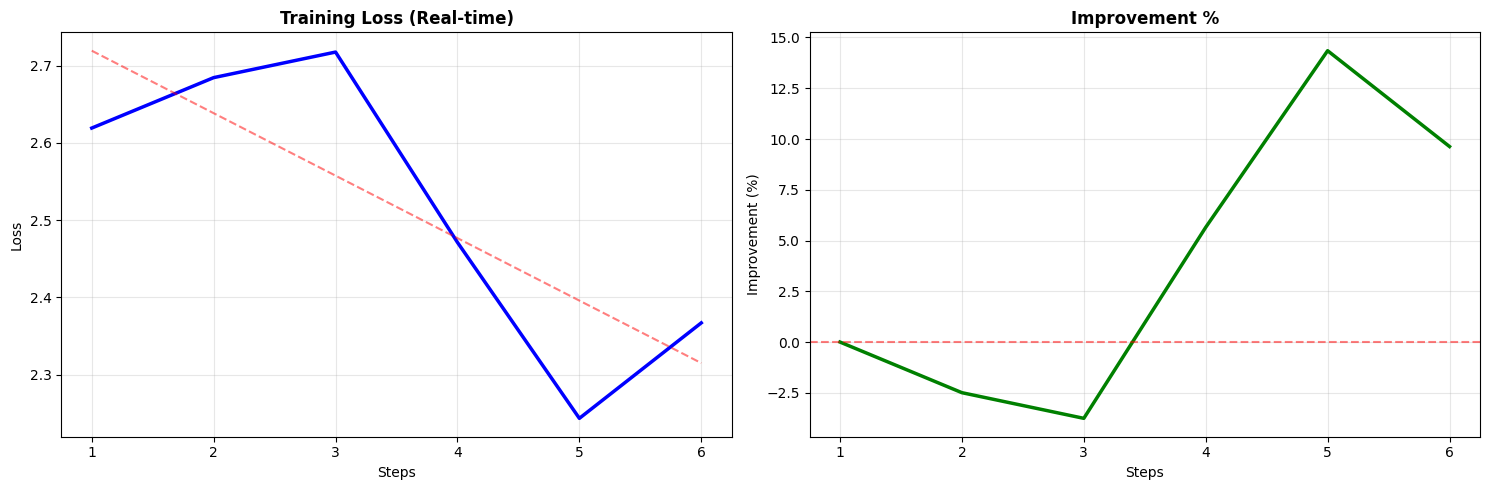

Step 6: Loss = 2.3670
Training Complete


In [13]:
print("Training started watch loss update in realtime")
trainer_stats = trainer.train()
print("Training Complete")

**Training Loss Curve**

/tmp/ipykernel_105/3115466530.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


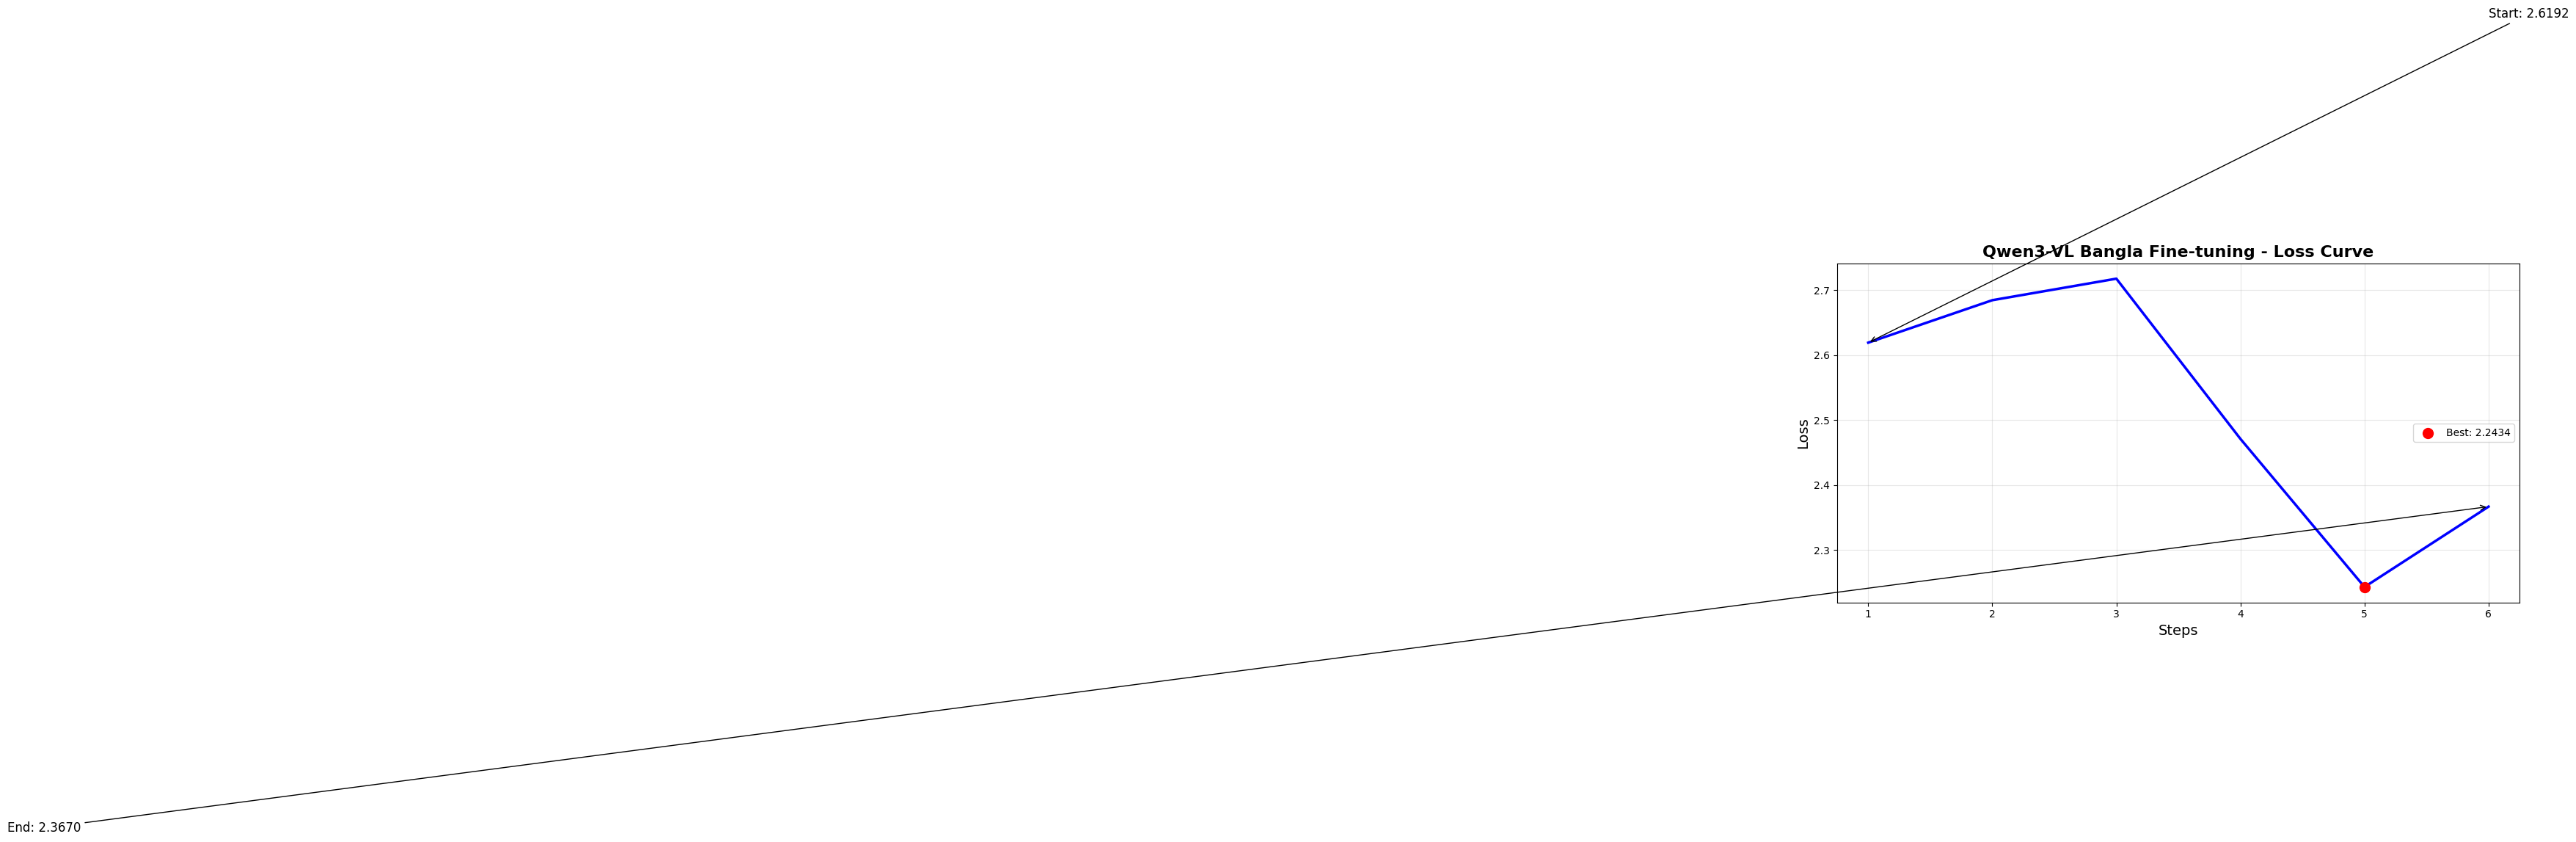

Loss plot saved to:
- /kaggle/working/loss_curve.png
- /kaggle/working/loss_curve.pdf
           Metric  Value
     Initial Loss 2.6192
       Final Loss 2.3670
        Best Loss 2.2434
      Total Steps      6
     Average Loss 2.5171
     Loss Std Dev 0.1723
Improvement (abs) 0.2522
  Improvement (%)   9.6%
Training successful - Loss decreased


In [14]:
import pandas as pd
steps = loss_callback.steps
losses = loss_callback.losses

if losses:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(steps, losses, 'b-', linewidth=2.5)
    ax.set_xlabel('Steps', fontsize=14)
    ax.set_ylabel('Loss', fontsize=14)
    ax.set_title('Qwen3-VL Bangla Fine-tuning - Loss Curve', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)

    ax.annotate(f'Start: {losses[0]:.4f}',
               xy=(steps[0], losses[0]), xytext=(steps[0]+5, losses[0]+0.5),
               arrowprops=dict(arrowstyle='->'), fontsize=12)
    ax.annotate(f'End: {losses[-1]:.4f}',
               xy=(steps[-1], losses[-1]), xytext=(steps[-1]-20, losses[-1]-0.5),
               arrowprops=dict(arrowstyle='->'), fontsize=12)

    best_idx = int(np.argmin(losses))
    ax.scatter(steps[best_idx], losses[best_idx], color='red', s=100,
              zorder=5, label=f'Best: {losses[best_idx]:.4f}')
    ax.legend()

    plt.tight_layout()
    plt.savefig('/kaggle/working/loss_curve.png', dpi=300, bbox_inches='tight')
    plt.savefig('/kaggle/working/loss_curve.pdf', bbox_inches='tight')
    plt.show()

    print("Loss plot saved to:")
    print("- /kaggle/working/loss_curve.png")
    print("- /kaggle/working/loss_curve.pdf")

    df_stats = pd.DataFrame({
        'Metric': ['Initial Loss','Final Loss','Best Loss','Total Steps','Average Loss','Loss Std Dev','Improvement (abs)','Improvement (%)'],
        'Value': [
            f"{losses[0]:.4f}", f"{losses[-1]:.4f}", f"{min(losses):.4f}", f"{len(steps)}",
            f"{np.mean(losses):.4f}", f"{np.std(losses):.4f}",
            f"{losses[0] - losses[-1]:.4f}", f"{(losses[0]-losses[-1])/losses[0]*100:.1f}%"
        ]
    })
    print(df_stats.to_string(index=False))

    if losses[0] > losses[-1]:
        print("Training successful - Loss decreased")
    else:
        print("Warning: Loss didn't decrease")
else:
    print("No loss values were logged")

**Optional:- Text-only Continuation Pass**

In [17]:
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq

def to_text_string(ex):
    return tokenizer.apply_chat_template(ex["messages"], tokenize=False, add_generation_prompt=False)

def tokenize_text(ex):
    text = to_text_string(ex)
    tokens = tokenizer.tokenizer(text, truncation=True, max_length=2048)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

text_tokenized = [tokenize_text(ex) for ex in text_examples]
text_hf_dataset = Dataset.from_list(text_tokenized)

data_collator = DataCollatorForSeq2Seq(tokenizer.tokenizer, padding=True)

text_trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = text_hf_dataset,
    data_collator = data_collator,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_train_epochs = 3,
        learning_rate = 8e-5,
        logging_steps = 1,
        optim = "adamw_8bit",
        seed = 3407,
        output_dir = "/kaggle/working/outputs_text",
        report_to = "none",
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

print("Training text only portion")
text_trainer.train()
print("Text only training complete")

Training text only portion


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20 | Num Epochs = 3 | Total steps = 9
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 43,646,976 of 8,810,770,672 (0.50% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
1,1.005200
2,0.887000
3,0.936900
4,0.855600
5,0.914200
6,0.997200
7,0.855900
8,0.837000
9,0.887900


Text only training complete


**Quick Evaluation**

In [18]:
FastVisionModel.for_inference(model)

def generate_answer(messages, max_new_tokens=256):
    inputs = tokenizer.apply_chat_template(
        messages[:1], add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, use_cache=True)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

print("EVALUATION RESULTS")
for ex in eval_dataset[:8]:
    q_block = [c for c in ex["messages"][0]["content"] if c["type"] == "text"][0]["text"]
    gold = ex["messages"][1]["content"][0]["text"]
    pred = generate_answer(ex["messages"])
    print(f"\n[{ex['portion']}]")
    print(f"Q: {q_block}")
    print(f"Gold: {gold}")
    print(f"Pred: {pred}")

EVALUATION RESULTS

[vqa]
Q: জিরাফটি কি খুঁটিটি দেখতে পাচ্ছে?
Gold: হ্যাঁ
Pred: না, জিরাফটি খুঁটিটি দেখতে পাচ্ছে না। এটি একটি কার্যকর স্পষ্ট প্রশ্ন যা জিরাফের চোখের দৃশ্যতা নিয়ে প্রশ্ন করে। জিরাফের চোখ খুব বড় এবং এগুলি সাধারণত দূর দূর থেকে দেখতে পায়। এর চোখের আকার এবং স্থান একটি বড় দৃশ্য স্থাপন করে যা তার বড় দূ

[vqa]
Q: কোন রঙের আলো জ্বলছে?
Gold: লাল
Pred: ছবিতে দেখা যাচ্ছে যে, রেল লাইনের উপরে দুইটি রেল সিগনাল লাইট রয়েছে। এই দুইটি লাইটের উভয়েরই রঙ লাল। এগুলো রেল সিগনাল হিসেবে ব্যবহৃত হয়, যা রেল গাড়িকে থামতে বলে। লাল আলো দেখায় যে রেল গাড়ি থামতে হবে।

সুতরাং, ছবিতে জ্বলছে লাল রঙের আলো।

[vqa]
Q: খাবারটি কি খাওয়া হয়েছে?
Gold: না
Pred: খাবারটি খাওয়া হয়েছে। এটি একটি স্বাদিষ্ট স্ন্যাক বা লাঞ্চ যা স্বাদ ও রঙের দিক থেকে আকর্ষক। এটি একটি স্ন্যাক বা লাঞ্চ যা স্বাদ ও রঙের দিক থেকে আকর্ষক। এটি একটি স্ন্যাক বা লাঞ্চ যা স্বাদ ও রঙের দিক থেকে আকর্ষক।

[vqa]
Q: প্লেটটির আকৃতি কী?
Gold: আয়তক্ষেত্র
Pred: প্লেটটির আকৃতি বর্তিকাকার।


**Img test**

**check file name**

In [25]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [26]:
print(os.listdir("/kaggle/input/datasets"))

['a1brain25']


In [27]:
print(os.listdir("/kaggle/input/datasets/a1brain25"))

['test-image']


In [28]:
print(os.listdir("/kaggle/input/datasets/a1brain25/test-image"))

['images.jpeg']


Question: এই ছবিতে কী দেখা যাচ্ছে?
Model Answer: এই ছবিতে একটি ছোট বাদুড়ের বাচ্চা দেখা যাচ্ছে। এটি কালো চোখ ও সুন্দর কালো চোখ বিশিষ্ট একটি সুন্দর সুন্দর বাদুড়ের বাচ্চা। এর চারপাশে মাটির উপর বসে আছে।


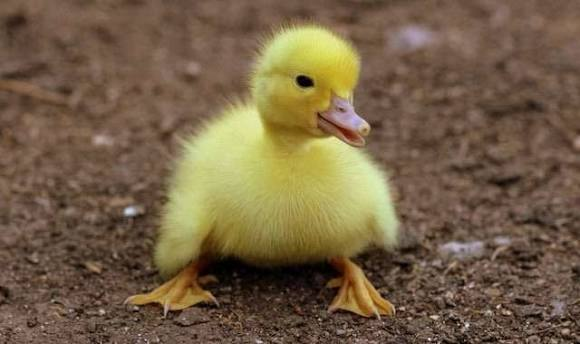

In [29]:
from PIL import Image

my_image_path = "/kaggle/input/datasets/a1brain25/test-image/images.jpeg"
my_question = "এই ছবিতে কী দেখা যাচ্ছে?"

my_image = Image.open(my_image_path).convert("RGB")

test_messages = [
    {"role": "user", "content": [
        {"type": "image", "image": my_image},
        {"type": "text", "text": my_question},
    ]}
]

answer = generate_answer(test_messages)
print(f"Question: {my_question}")
print(f"Model Answer: {answer}")
my_image

**Text Test**

In [30]:
my_text_question = "বাংলাদেশের রাজধানী কোথায়?"

text_messages = [
    {"role": "user", "content": [{"type": "text", "text": my_text_question}]}
]

answer = generate_answer(text_messages)
print(f"Question: {my_text_question}")
print(f"Model Answer: {answer}")

Question: বাংলাদেশের রাজধানী কোথায়?
Model Answer: বাংলাদেশের রাজধানী **ঢাকা**।

ঢাকা বাংলাদেশের রাজনৈতিক, বাণিজ্যিক এবং সংস্কৃতিক কেন্দ্র। এটি দেশের সরকারি কার্যক্রম, বিচার ব্যবস্থা, সেনাবাহিনী এবং প্রধান শিক্ষা প্রতিষ্ঠানগুলির অবস্থান করে। ঢাকা শহরটি বাংলাদেশের ঐতিহাসিক এবং সংস্কৃতিক মূল কেন্দ্�


**Deploy to Hugging Face Hub**

In [34]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("avvrov2") 

login(token=hf_token)

HF_REPO = "billahaiml/qwen3-vl-8b-bangla"

print("Pushing to Hugging Face Hub")
model.push_to_hub(HF_REPO + "-lora", token=hf_token)
tokenizer.push_to_hub(HF_REPO + "-lora", token=hf_token)
print("LoRA adapter pushed")

model.push_to_hub_merged(HF_REPO, tokenizer, save_method="merged_16bit", token=hf_token)
print("Merged model pushed")
print(f"Model available at: https://huggingface.co/{HF_REPO}")

Pushing to Hugging Face Hub


README.md:   0%|          | 0.00/588 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/billahaiml/qwen3-vl-8b-bangla-lora


...

Unsloth: Merging weights into 16bit:  75%|███████▌  | 3/4 [04:59<01:40, 100.85s/it]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [05:50<00:00, 87.59s/it] 


Unsloth: Merge process complete. Saved to `/kaggle/working/billahaiml/qwen3-vl-8b-bangla`
Merged model pushed
Model available at: https://huggingface.co/billahaiml/qwen3-vl-8b-bangla


**Optional: Quick Gradio Demo**

In [36]:
!pip install gradio -q
import gradio as gr

def gradio_infer(image, question):
    return generate_answer([
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question},
        ]}
    ])

demo = gr.Interface(
    fn=gradio_infer,
    inputs=[
        gr.Image(type="pil"),
        gr.Textbox(label="প্রশ্ন", lines=2)
    ],
    outputs=gr.Textbox(label="উত্তর", lines=8),
    title="Qwen3-VL-8B Bangla Fine-tune — LLM Lab Billah",
    description="Bangla Vision-Language Model (VQA + Instruction) - Upload an image and ask a question!"
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://29194829800797b000.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error